# CS-4063 NLP Assignment 2

This notebook is a simple runner and result presenter for all three parts.
All core implementations are in `scripts/` and are executed from cells below.

- Student: i23-2523
- Assignment: Neural NLP Pipeline
- Framework: PyTorch from scratch

In [1]:
# Sections 1-2: configuration, reproducibility, dependency snapshot, and scaffold
import os
import sys
import json
import random
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ROOT = Path('.').resolve()
PYTHON = ROOT / '.venv' / 'Scripts' / 'python.exe'

EMBED_DIR = ROOT / 'embeddings'
MODEL_DIR = ROOT / 'models'
DATA_DIR = ROOT / 'data'
FIG_DIR = ROOT / 'figures'
SCRIPT_DIR = ROOT / 'scripts'

for p in [EMBED_DIR, MODEL_DIR, DATA_DIR, FIG_DIR, SCRIPT_DIR]:
    p.mkdir(exist_ok=True)

print('Root:', ROOT)
print('Python:', PYTHON)
print('Seed:', SEED)
print('Python version:', sys.version.split()[0])

packages = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'scikit-learn', 'torch', 'seqeval', 'requests', 'beautifulsoup4']
for pkg in packages:
    print('-', pkg)

Root: D:\Work\Semester6\NLP\Assignments\Asst-2
Python: D:\Work\Semester6\NLP\Assignments\Asst-2\.venv\Scripts\python.exe
Seed: 42
Python version: 3.14.0
- numpy
- pandas
- matplotlib
- seaborn
- scikit-learn
- torch
- seqeval
- requests
- beautifulsoup4


In [2]:
# Sections 3-4: regenerate base artifacts and integrity checks
need_base = not ((ROOT / 'raw.txt').exists() and (ROOT / 'cleaned.txt').exists() and (ROOT / 'Metadata.json').exists())
if need_base:
    cmd = [str(PYTHON), str(SCRIPT_DIR / 'generate_base_corpus.py'), '--target_count', '240', '--sleep', '0.1', '--min_body_chars', '250']
    print('Running:', ' '.join(cmd))
    subprocess.run(cmd, check=True)
else:
    print('Base files already exist, skipping regeneration.')

if (ROOT / 'metadata.json').exists() and not (ROOT / 'Metadata.json').exists():
    (ROOT / 'Metadata.json').write_text((ROOT / 'metadata.json').read_text(encoding='utf-8'), encoding='utf-8')

print('raw.txt exists:', (ROOT / 'raw.txt').exists())
print('cleaned.txt exists:', (ROOT / 'cleaned.txt').exists())
print('Metadata.json exists:', (ROOT / 'Metadata.json').exists())

meta = json.loads((ROOT / 'Metadata.json').read_text(encoding='utf-8'))
print('Metadata article count:', len(meta))

with open(ROOT / 'raw.txt', 'r', encoding='utf-8') as f:
    raw_head = [next(f).rstrip('\n') for _ in range(3)]
print('Raw preview:')
for line in raw_head:
    print(line)

Base files already exist, skipping regeneration.
raw.txt exists: True
cleaned.txt exists: True
Metadata.json exists: True
Metadata article count: 240
Raw preview:
[1]
ایک ایسے وقت میں جب پاکستان کے فیلڈ مارشل عاصم منیر وفد کے ہمراہ ایران میں موجود ہیں، یہ خیال تقویض پکڑ چکا ہے کہ امریکہ ایران کے ساتھ جنگ بندی بات چیت کے دوسرے مرحلے پر غور کر رہا ہے۔
پاکستان کی میزبانی میں ہونے والی امریکہ ایران بات چیت 20 گھنٹے جاری رہنے کے بعد کسی نتیجے پر پہنچے بغیر ختم ہوئی تھی تاہم دو ہفتوں کی جنگ بندی اب بھی برقرار ہے۔


In [3]:
# Sections 5-13: vocab, TF-IDF, PPMI, t-SNE, skip-gram, evaluation, C1-C4
required_part1 = [
    EMBED_DIR / 'word2idx.json',
    EMBED_DIR / 'tfidf_matrix.npy',
    EMBED_DIR / 'ppmi_matrix.npy',
    EMBED_DIR / 'embeddings_w2v.npy',
    EMBED_DIR / 'part1_report.json',
]
if not all(p.exists() for p in required_part1):
    cmd = [str(PYTHON), str(SCRIPT_DIR / 'part1_embeddings.py')]
    print('Running:', ' '.join(cmd))
    subprocess.run(cmd, check=True)
else:
    print('Part 1 artifacts already exist, skipping training run.')

part1 = json.loads((EMBED_DIR / 'part1_report.json').read_text(encoding='utf-8'))
print('TF-IDF shape:', part1['tfidf_shape'])
print('PPMI shape:', part1['ppmi_shape'])
print('Analogy correct count:', part1['analogy_correct_count'])
print('Best condition:', part1['best_condition'])
print('MRR:', part1['condition_mrr'])

Part 1 artifacts already exist, skipping training run.
TF-IDF shape: [240, 10001]
PPMI shape: [10001, 10001]
Analogy correct count: 7
Best condition: C1_PPMI
MRR: {'C1_PPMI': 0.05244902167533707, 'C2_Skipgram_raw': 0.0007906867561568486, 'C3_Skipgram_cleaned': 0.0006144894969389702, 'C4_Skipgram_cleaned_d200': 0.0015327890916836783}


Top-10 discriminative terms per topic (first 5 shown):

 Economy
  جہاز: 13.0884
  ایران: 12.4069
  تیل: 11.1917
  ناکہ: 11.0489
  ابنای: 9.5029

 Politics
  ایران: 7.3506
  نیند: 4.2655
  بجل: 4.0804
  نواز: 3.7815
  اصف: 3.5186

 International
  سعو: 7.9466
  ایران: 7.6541
  عرب: 6.6715
  فلم: 6.6235
  پاکستان: 5.8464

 Sports
  کرکٹ: 10.2066
  ٹیم: 9.7086
  میچ: 8.4795
  کھلاڑ: 7.0090
  کھیل: 6.8660

 HealthSociety
  ڈاکٹر: 16.0783
  ایچ: 14.9295
  اشا: 14.2281
  نیند: 13.8629
  چودھر: 13.5498

Required query neighbors from C3:
Pakistan (پاکستان): ['اور', 'اٹھ', 'ای', 'مطابق', 'بم']
Hukumat (حکومت): ['بڑ', 'چمن', 'پہنا', 'فضا', 'لسٹڈ']
Adalat (عدالت): ['نااہل', 'جناب', 'ٹھکرا', 'زچ', 'وانگ']
Maeeshat (معیشت): ['ڈیڈ', 'کھردرا', 'حبش', 'مشہور', 'واشنگ']
Fauj (فوج): ['اندرون', 'شورش', 'شد', 'ٹکڑا', 'ملبہ']
Sehat (صحت): ['کاہن', 'گہم', 'کامل', 'پشپیندر', 'مساو']
Taleem (تعلیم): ['معمور', 'کیارا', 'انگوٹھ', 'ٹرینڈ', 'فرزند']
Aabadi (اباد): ['بلکہ', 'گولڈن', 'پھیلای', 'سسک', 'سینیٹر']

Fo

,Condition,MRR
0,C1_PPMI,0.052449
3,C4_Skipgram_cleaned_d200,0.001533
1,C2_Skipgram_raw,0.000791
2,C3_Skipgram_cleaned,0.000614


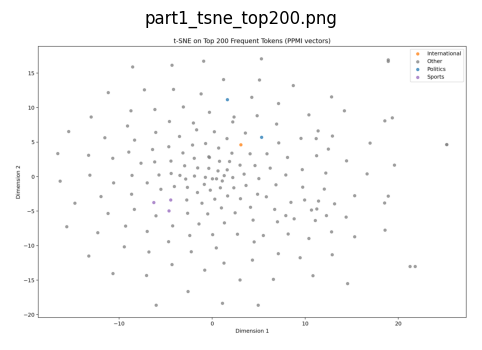

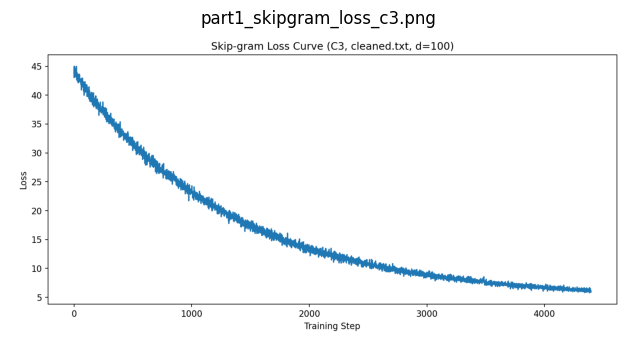

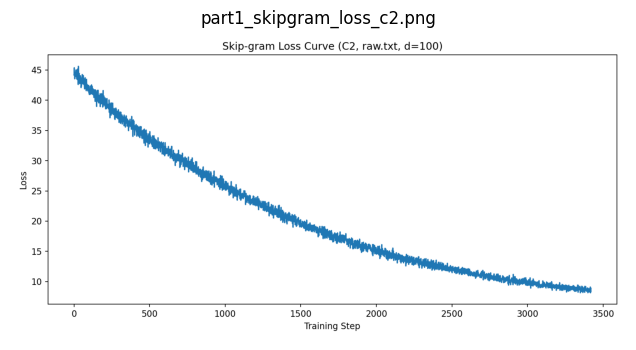

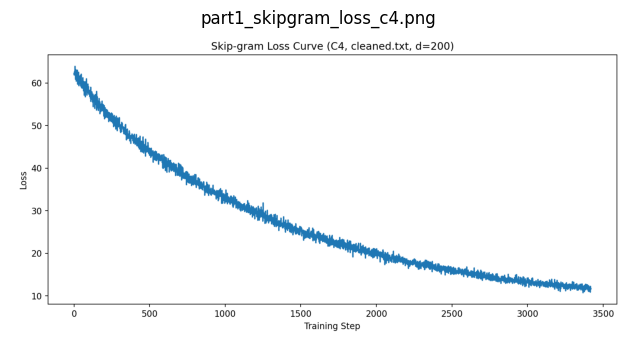

In [4]:
# Sections 6, 7, 8, 11, 12, 13: detailed Part 1 reporting
mrr_df = pd.DataFrame(part1['condition_mrr'].items(), columns=['Condition', 'MRR']).sort_values('MRR', ascending=False)
print('Top-10 discriminative terms per topic (first 5 shown):')
for topic, vals in part1['top_words_per_topic'].items():
    print('\n', topic)
    for word, score in vals[:5]:
        print(f'  {word}: {score:.4f}')

print('\nRequired query neighbors from C3:')
for q, payload in part1['required_neighbors_c3'].items():
    n = [x[0] for x in payload['neighbors'][:5]]
    print(f"{q} ({payload['used_query']}): {n}")

print('\nFour-condition MRR table:')
display(mrr_df)

figs = [
    ROOT / 'figures' / 'part1_tsne_top200.png',
    ROOT / 'figures' / 'part1_skipgram_loss_c3.png',
    ROOT / 'figures' / 'part1_skipgram_loss_c2.png',
    ROOT / 'figures' / 'part1_skipgram_loss_c4.png',
]
for fp in figs:
    if fp.exists():
        img = plt.imread(fp)
        plt.figure(figsize=(10, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title(fp.name)
        plt.show()

In [5]:
# Sections 14-20: sentence sampling, POS/NER annotation, BiLSTM(+CRF), metrics, ablations
required_part2 = [
    DATA_DIR / 'pos_train.conll',
    DATA_DIR / 'pos_test.conll',
    DATA_DIR / 'ner_train.conll',
    DATA_DIR / 'ner_test.conll',
    DATA_DIR / 'part2_report.json',
    MODEL_DIR / 'bilstm_pos.pt',
    MODEL_DIR / 'bilstm_ner.pt',
]
if not all(p.exists() for p in required_part2):
    cmd = [str(PYTHON), str(SCRIPT_DIR / 'part2_sequence_labeling.py')]
    print('Running:', ' '.join(cmd))
    subprocess.run(cmd, check=True)
else:
    print('Part 2 artifacts already exist, skipping training run.')

part2 = json.loads((DATA_DIR / 'part2_report.json').read_text(encoding='utf-8'))
print('Sentence count:', part2['sentence_count'])
print('Lexicon sizes:', part2['lexicon_sizes'])
print('Split sizes:', part2['split_sizes'])
print('POS frozen vs fine-tuned val F1:', part2['pos_results']['frozen_val_f1'], part2['pos_results']['finetuned_val_f1'])
print('POS test accuracy / macro-F1:', part2['pos_results']['test_accuracy'], part2['pos_results']['test_macro_f1'])
print('NER test F1 CRF vs softmax:', part2['ner_results']['test_overall_f1_crf'], part2['ner_results']['test_overall_f1_softmax'])

Part 2 artifacts already exist, skipping training run.
Sentence count: 500
Lexicon sizes: {'noun': 220, 'verb': 220, 'adj': 220, 'per_gazetteer': 61, 'loc_gazetteer': 58, 'org_gazetteer': 33}
Split sizes: {'train': 350, 'val': 75, 'test': 75}
POS frozen vs fine-tuned val F1: 0.4852023984063915 0.8058068353860044
POS test accuracy / macro-F1: 0.8493438320209974 0.8166429855197971
NER test F1 CRF vs softmax: 0.12307692307692307 0.7068965517241379


POS train distribution:


,count
VERB,2768
NOUN,2569
POST,1400
PRON,678
AUX,474
CONJ,315
ADJ,242
DET,102
ADV,91
UNK,80


NER train distribution:


,count
O,8554
B-LOC,119
B-ORG,71
B-PER,28
I-ORG,28
B-MISC,12
I-LOC,2
I-PER,2


Top confused POS pairs:


,pair,count,examples
0,NOUN->VERB,253,[بنگلہ دیش کی ٹیم نے مقررہ <NUM> اوورز میں پان...
1,ADJ->VERB,10,[بنگلہ دیش کی ٹیم نے مقررہ <NUM> اوورز میں پان...
2,ADJ->NOUN,7,[جس وجہ سے کی مواقع پر انفیکشن کنٹرول پروگرام ...


NER CRF entity report keys: ['LOC', 'MISC', 'ORG', 'PER', 'micro avg', 'macro avg']
Ablation scores:


,Ablation,Test F1
0,A1_unidirectional_lstm,0.683333
1,A2_no_dropout,0.660550
2,A3_random_embeddings,0.613861
3,A4_softmax_instead_of_crf,0.706897


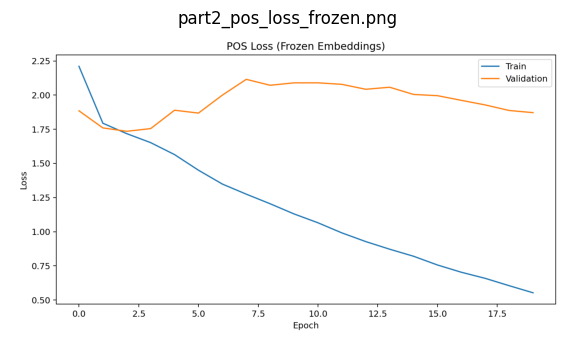

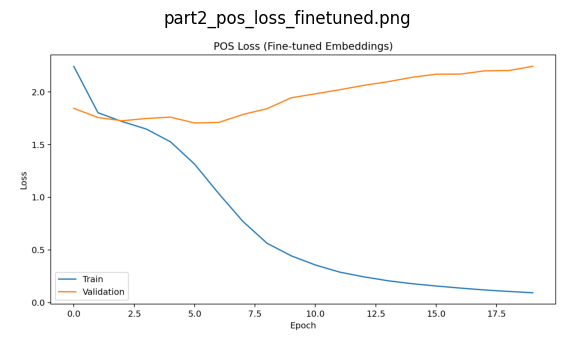

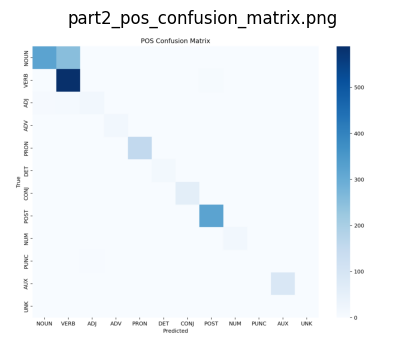

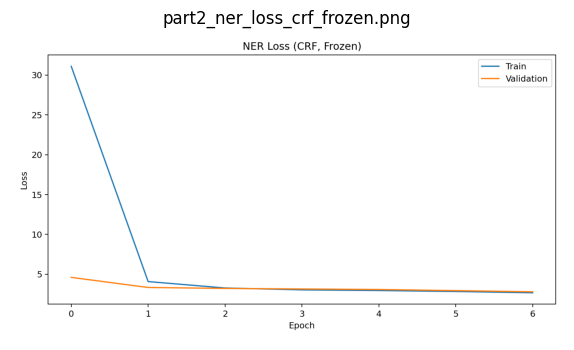

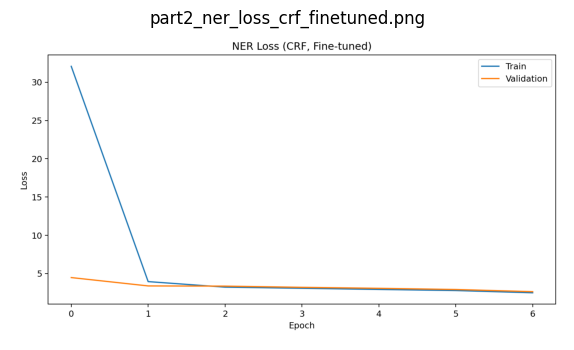

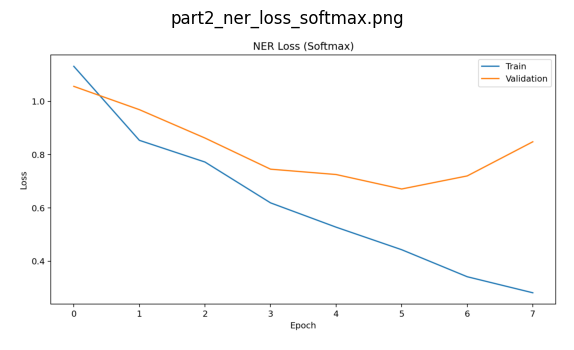

In [6]:
# Sections 15, 18, 19, 20: Part 2 distributions, confusion analysis, NER analysis, ablations
pos_dist_train = pd.Series(part2['label_distribution']['pos']['train']).sort_values(ascending=False)
ner_dist_train = pd.Series(part2['label_distribution']['ner']['train']).sort_values(ascending=False)

print('POS train distribution:')
display(pos_dist_train.to_frame('count'))

print('NER train distribution:')
display(ner_dist_train.to_frame('count'))

print('Top confused POS pairs:')
display(pd.DataFrame(part2['pos_results']['top_confused_pairs']))

print('NER CRF entity report keys:', [k for k in part2['ner_results']['entity_report_crf'].keys() if k in ['PER', 'LOC', 'ORG', 'MISC', 'micro avg', 'macro avg']])
print('Ablation scores:')
display(pd.DataFrame(part2['ablations'].items(), columns=['Ablation', 'Test F1']))

part2_figs = [
    ROOT / 'figures' / 'part2_pos_loss_frozen.png',
    ROOT / 'figures' / 'part2_pos_loss_finetuned.png',
    ROOT / 'figures' / 'part2_pos_confusion_matrix.png',
    ROOT / 'figures' / 'part2_ner_loss_crf_frozen.png',
    ROOT / 'figures' / 'part2_ner_loss_crf_finetuned.png',
    ROOT / 'figures' / 'part2_ner_loss_softmax.png',
]
for fp in part2_figs:
    if fp.exists():
        img = plt.imread(fp)
        plt.figure(figsize=(10, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title(fp.name)
        plt.show()

In [7]:
# Sections 21-24: topic dataset, custom transformer, training, evaluation, confusion matrix, attention heatmaps
required_part3 = [
    DATA_DIR / 'part3_report.json',
    DATA_DIR / 'part3_bilstm_vs_transformer.txt',
    MODEL_DIR / 'transformer_cls.pt',
]
if not all(p.exists() for p in required_part3):
    cmd = [str(PYTHON), str(SCRIPT_DIR / 'part3_transformer_classifier.py')]
    print('Running:', ' '.join(cmd))
    subprocess.run(cmd, check=True)
else:
    print('Part 3 artifacts already exist, skipping training run.')

part3 = json.loads((DATA_DIR / 'part3_report.json').read_text(encoding='utf-8'))
print('Class distribution (train):', part3['class_distribution']['train'])
print('Transformer test acc / macro-F1:', part3['transformer']['test_acc'], part3['transformer']['test_macro_f1'])
print('BiLSTM test acc / macro-F1:', part3['bilstm_baseline']['test_acc'], part3['bilstm_baseline']['test_macro_f1'])

Part 3 artifacts already exist, skipping training run.
Class distribution (train): {'Politics': 34, 'International': 60, 'Economy': 16, 'HealthSociety': 26, 'Sports': 32}
Transformer test acc / macro-F1: 0.5555555555555556 0.5509661391240339
BiLSTM test acc / macro-F1: 0.4166666666666667 0.43365223012281834


1. Transformer test accuracy was 0.5556 while BiLSTM test accuracy was 0.4167.
2. The accuracy gap was 0.1389, so Transformer performed better.
3. Transformer reached best validation accuracy at epoch 16.
4. BiLSTM reached best validation accuracy at epoch 18.
5. This means Transformer converged in fewer epochs.
6. Average training time per epoch for Transformer was 0.50 seconds.
7. Average training time per epoch for BiLSTM was 5.59 seconds.
8. In this run, Transformer trained faster per epoch.
9. A likely reason is that its implementation is highly vectorized on GPU, while recurrent processing in BiLSTM is less parallel-friendly.
10. The attention heatmaps show that final-layer heads focus strongly on a few topic-indicative tokens.
11. Some heads focus near the [CLS] token while others focus on repeated category keywords.
12. This indicates the Transformer learns where to read evidence for class decisions.
13. For only 200-300 articles, Transformer appears more appropriate in this ex

,Model,Test Accuracy,Macro-F1,Best Val Epoch
0,BiLSTM,0.416667,0.433652,18
1,Transformer,0.555556,0.550966,16


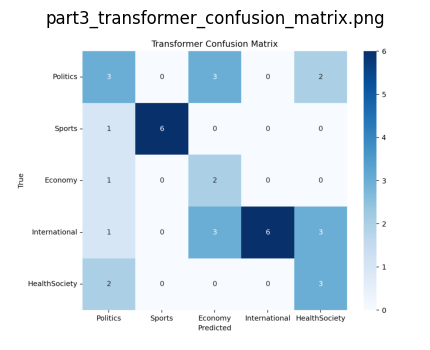

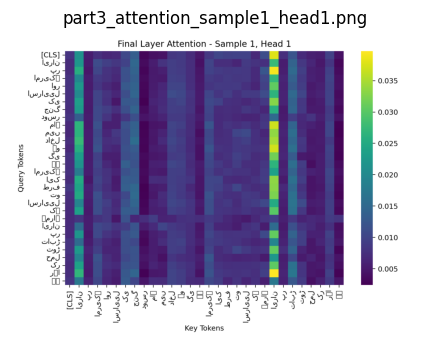

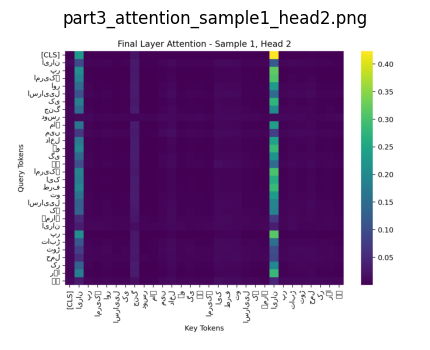

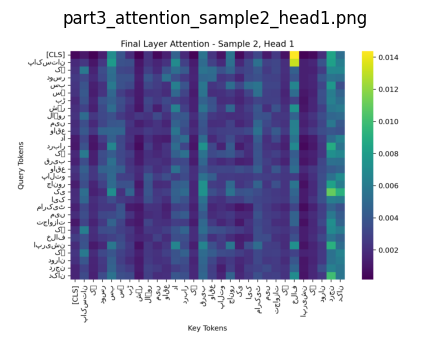

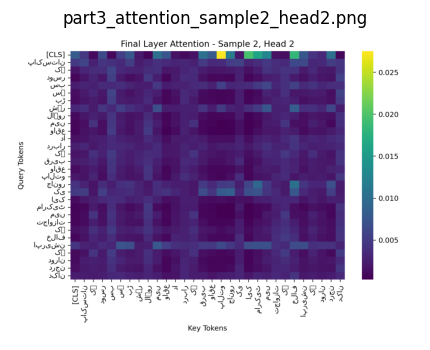

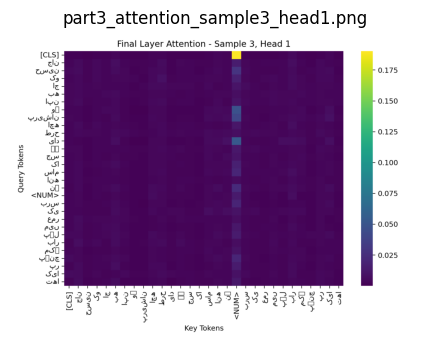

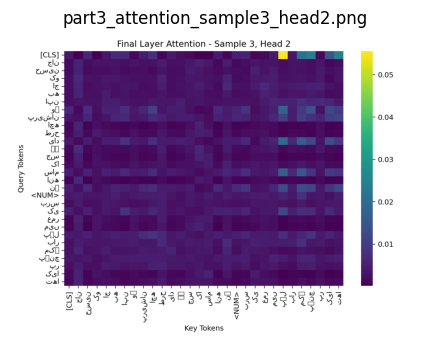

In [8]:
# Section 25: BiLSTM vs Transformer written comparison and result table
comparison_text = (DATA_DIR / 'part3_bilstm_vs_transformer.txt').read_text(encoding='utf-8')
print(comparison_text)

comp_df = pd.DataFrame([
    ['BiLSTM', part3['bilstm_baseline']['test_acc'], part3['bilstm_baseline']['test_macro_f1'], part3['bilstm_baseline']['best_epoch']],
    ['Transformer', part3['transformer']['test_acc'], part3['transformer']['test_macro_f1'], part3['transformer']['best_epoch']],
], columns=['Model', 'Test Accuracy', 'Macro-F1', 'Best Val Epoch'])

display(comp_df)

part3_figs = [
    ROOT / 'figures' / 'part3_transformer_loss_curve.png',
    ROOT / 'figures' / 'part3_transformer_accuracy_curve.png',
    ROOT / 'figures' / 'part3_bilstm_loss_curve.png',
    ROOT / 'figures' / 'part3_bilstm_accuracy_curve.png',
    ROOT / 'figures' / 'part3_transformer_confusion_matrix.png',
]
part3_figs.extend([Path(x) for x in part3.get('attention_heatmaps', [])])

for fp in part3_figs:
    if fp.exists():
        img = plt.imread(fp)
        plt.figure(figsize=(10, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title(fp.name)
        plt.show()

In [9]:
repo_url = 'https://github.com/ApatheticMioz/nlp-transformer-bilstm-pipeline'
print('GitHub repository:', repo_url)

GitHub repository: https://github.com/ApatheticMioz/nlp-transformer-bilstm-pipeline
